In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import seaborn as sns

In [2]:
timestamps = [datetime.now() + timedelta(seconds=i*10) for i in range(500)]

temperature = np.random.normal(loc=25, scale=2, size=500)
motion = np.random.normal(loc=0.5, scale=0.2, size=500)
sound_level = np.random.normal(loc=35, scale=5, size=500)

temperature[100:110] += 10
motion[250:255] += 1.5
sound_level[400:405] += 25

df = pd.DataFrame({
    'timestamp': timestamps,
    'temperature': temperature,
    'motion': motion,
    'sound_level': sound_level
})

df.to_csv("sensor_data.csv", index=False)
df.head()


,timestamp,temperature,motion,sound_level
0,2025-06-18 00:00:11.261617,23.007045,0.736048,38.391924
1,2025-06-18 00:00:21.261617,25.416844,0.768101,26.761241
2,2025-06-18 00:00:31.261617,24.793405,0.657146,32.564727
3,2025-06-18 00:00:41.261617,27.786240,0.280497,26.935813
4,2025-06-18 00:00:51.261617,26.374871,0.841874,34.531111


In [3]:
df = pd.read_csv("sensor_data.csv", parse_dates=['timestamp'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['temperature', 'motion', 'sound_level']])


In [5]:
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# ✅ This line creates the 'anomaly' column
df['anomaly'] = model.fit_predict(X_scaled)

# ✅ This converts: 1 → normal (0), -1 → anomaly (1)
df['anomaly'] = df['anomaly'].map({1: 0, -1: 1})


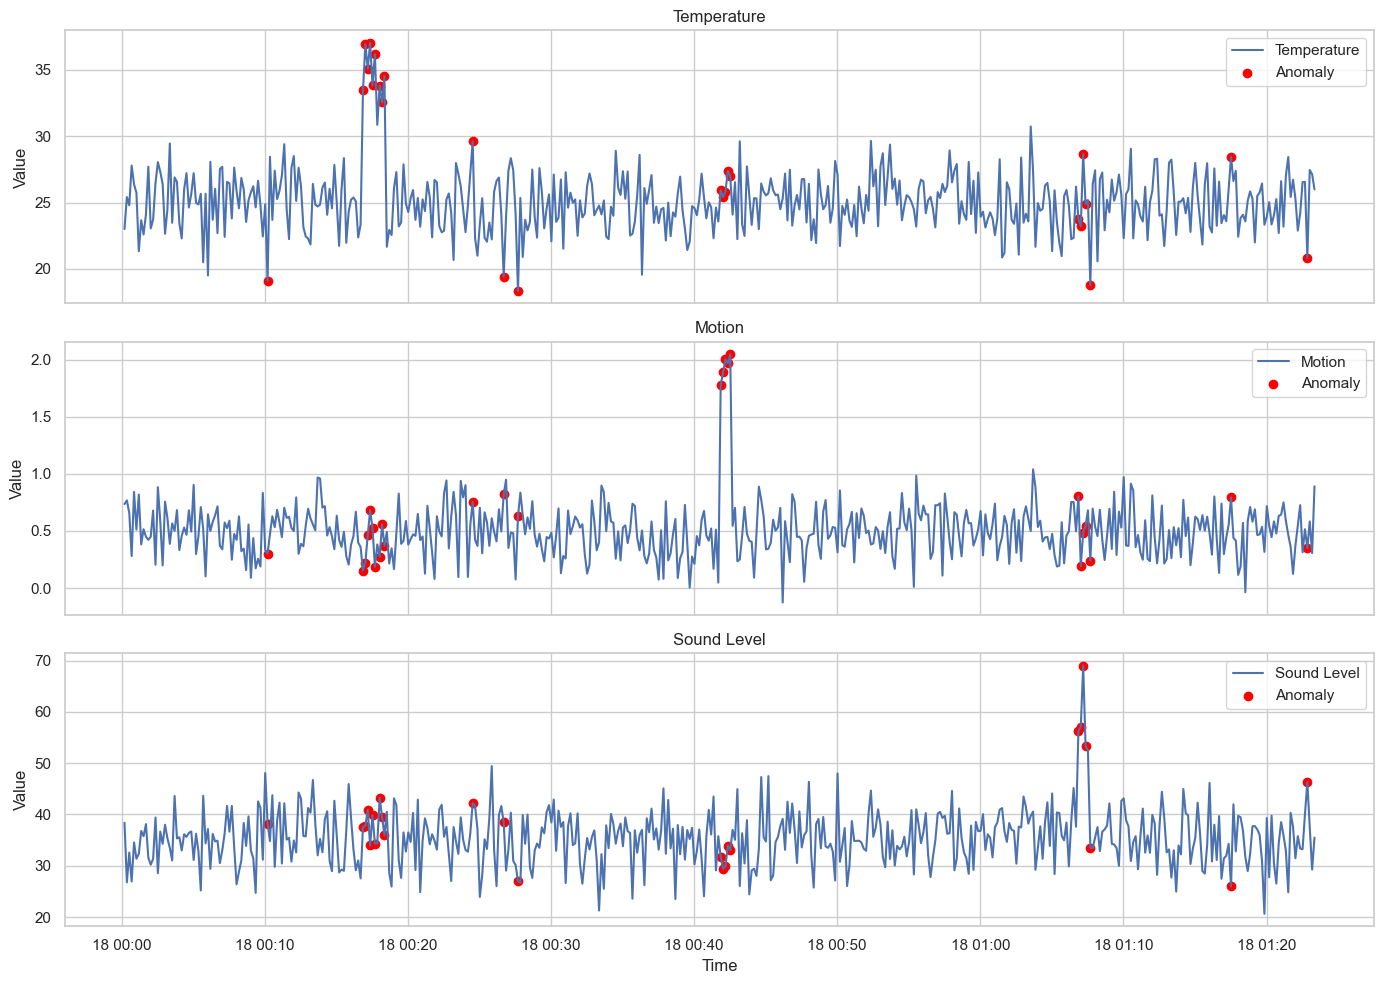

In [6]:
sns.set(style="whitegrid")
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axs[0].plot(df['timestamp'], df['temperature'], label='Temperature')
axs[0].scatter(df[df['anomaly']==1]['timestamp'], df[df['anomaly']==1]['temperature'], color='red', label='Anomaly')
axs[0].set_title("Temperature")

axs[1].plot(df['timestamp'], df['motion'], label='Motion')
axs[1].scatter(df[df['anomaly']==1]['timestamp'], df[df['anomaly']==1]['motion'], color='red', label='Anomaly')
axs[1].set_title("Motion")

axs[2].plot(df['timestamp'], df['sound_level'], label='Sound Level')
axs[2].scatter(df[df['anomaly']==1]['timestamp'], df[df['anomaly']==1]['sound_level'], color='red', label='Anomaly')
axs[2].set_title("Sound Level")

for ax in axs:
    ax.legend()
    ax.set_ylabel("Value")

plt.xlabel("Time")
plt.tight_layout()
plt.show()


In [7]:
import joblib
joblib.dump(model, "anomaly_detector_model.pkl")


['anomaly_detector_model.pkl']